<a href="https://colab.research.google.com/github/AlvaroAceval16/MachineLearning/blob/main/P3_Arboles_Regresion_Automobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cargar datos y Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
# https://drive.google.com/file/d/1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf/view?usp=drive_link
file_id = '1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf'

#URL de descarga directa
url = f'https://drive.google.com/uc?id={file_id}'

#Leer el archivo CSV directamente desde la URL
df = pd.read_csv(url)

# Manejar valores no numéricos y missing values
# Reemplazar '?' con NaN en las columnas relevantes
columns_to_process = ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore', 'price']
for col in columns_to_process:
    df[col] = df[col].replace('?', np.nan)

# Convertir las columnas a tipo numérico
for col in columns_to_process:
    df[col] = pd.to_numeric(df[col])

# Eliminar filas con valores NaN en las columnas de interés
df.dropna(subset=columns_to_process, inplace=True)

# Mostrar las primeras filas
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,13495.0
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,16500.0
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102.0,5500,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115.0,5500,18,22,17450.0


In [ ]:
# Definir Variables predictorias y variable objetivo
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [ ]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Entrenar modelo de regresion Lineal Multiple
tree_model = DecisionTreeRegressor(random_state = 42,max_depth = 4 )
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [ ]:
# Definir Variables predictorias y variable objetivo
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [ ]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Entrenar modelo de regresion Lineal Multiple
tree_model = DecisionTreeRegressor(random_state = 42,max_depth = 4 )
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [ ]:
# Evaluar Modelo
y_pred = tree_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R2): {r2:.2f}")

# Calcular el RMSE
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Error cuadrático medio (MSE): 16582621.74
Coeficiente de determinación (R2): 0.86
Raíz del Error cuadrático medio (RMSE): 4072.18


In [ ]:
# Coeficientes del modelo
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': tree_model.feature_importances_
})

print(coef_df)
# DecisionTreeRegressor does not have an 'intercept_' attribute.

      Variable  Importancia
0   horsepower     0.014230
1  engine-size     0.876006
2     city-mpg     0.011806
3   wheel-base     0.083098
4         bore     0.014859


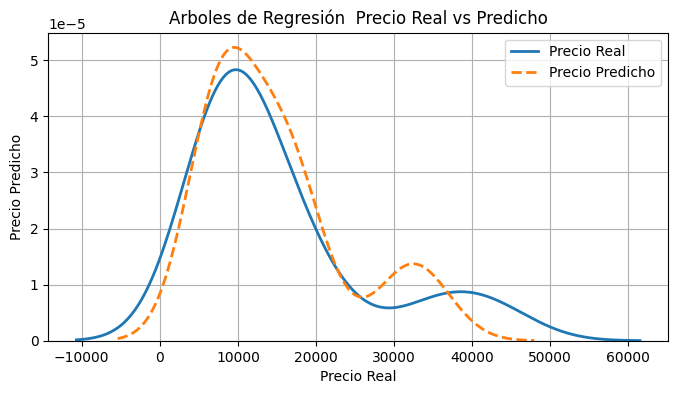

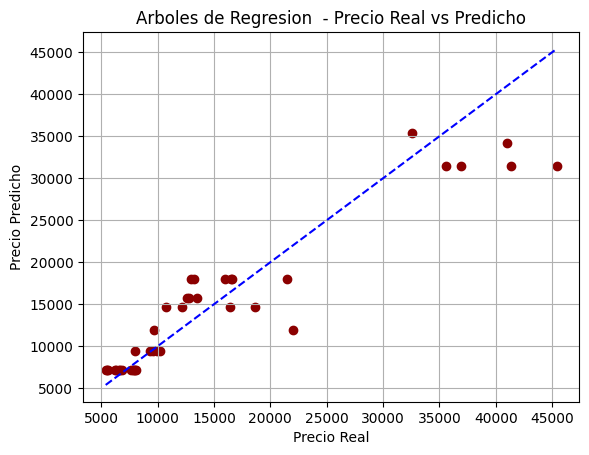

In [ ]:
# Comparar Precios Reales vs predichos
# Gráfica de densidad: Precio Real vs. Predicho
plt.figure(figsize=(8,4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de Regresión  Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica de dispersión: Precio Real vs. Predicho con línea ideal
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de Regresion  - Precio Real vs Predicho")
plt.grid(True)
plt.show()

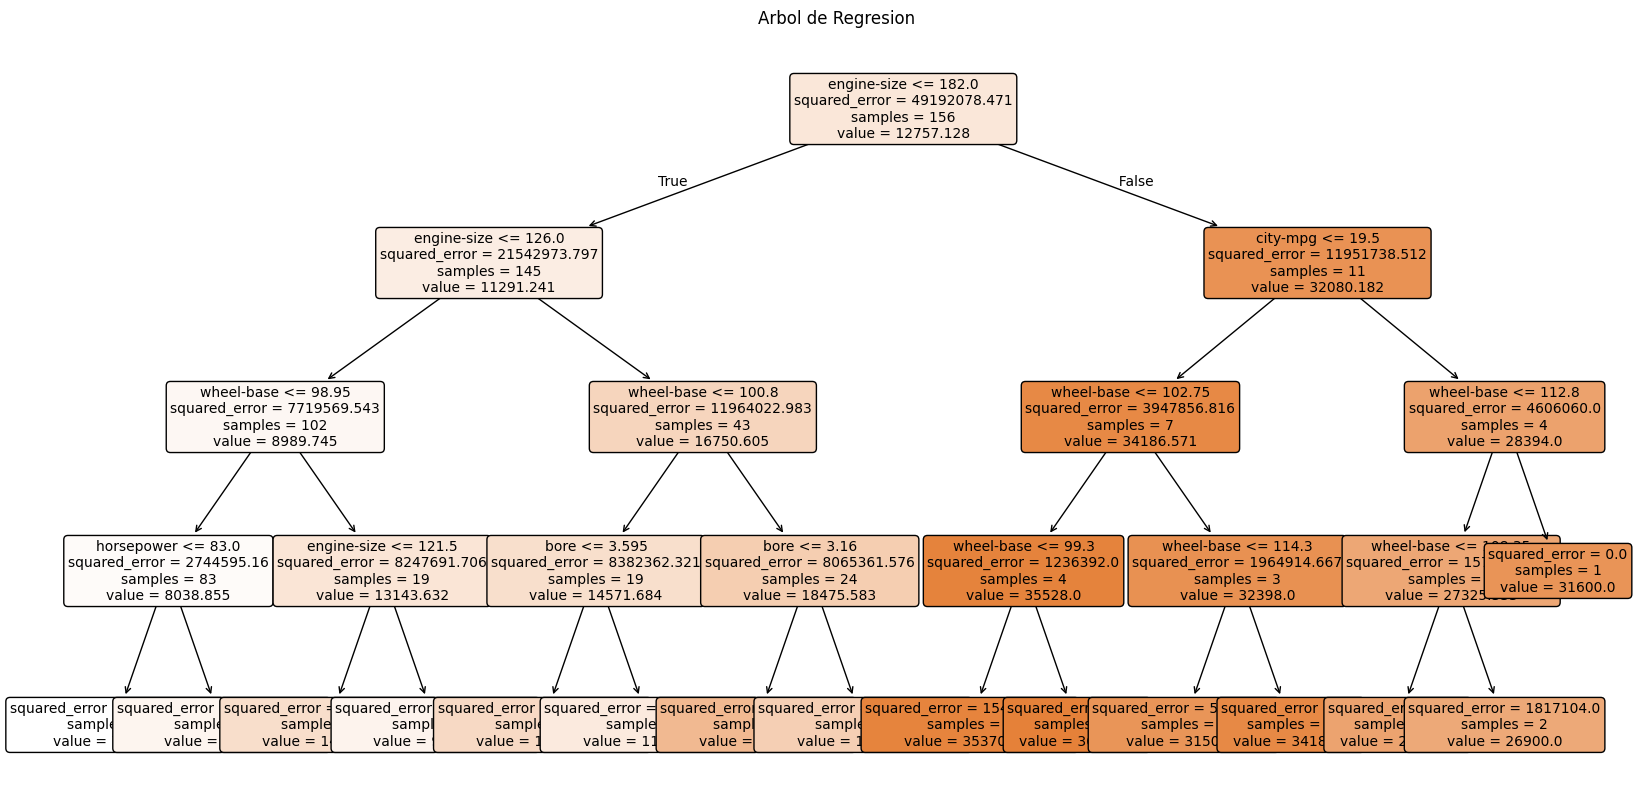

In [ ]:
# Impresion del Arbol de Decision
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Arbol de Regresion")
plt.show()


In [ ]:
# Ajustes de Parametros del Arbol de Decision

  # Entrenar modelo de regresion Lineal Multiple
tree_model = DecisionTreeRegressor(random_state = 42,max_depth = 9 )
tree_model.fit(X_train, y_train)

  # Evaluar Modelo
y_pred = tree_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R2): {r2:.2f}")

# Calcular el RMSE
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Error cuadrático medio (MSE): 21193991.31
Coeficiente de determinación (R2): 0.83
Raíz del Error cuadrático medio (RMSE): 4603.69


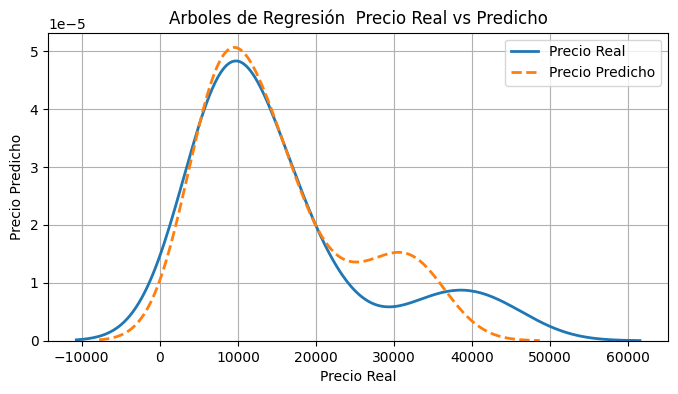

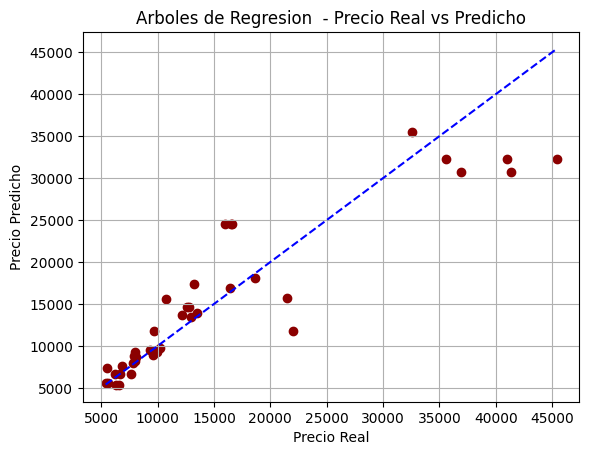

In [ ]:
# Comparar Precios Reales vs predichos
# Gráfica de densidad: Precio Real vs. Predicho
plt.figure(figsize=(8,4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de Regresión  Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica de dispersión: Precio Real vs. Predicho con línea ideal
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de Regresion  - Precio Real vs Predicho")
plt.grid(True)
plt.show()

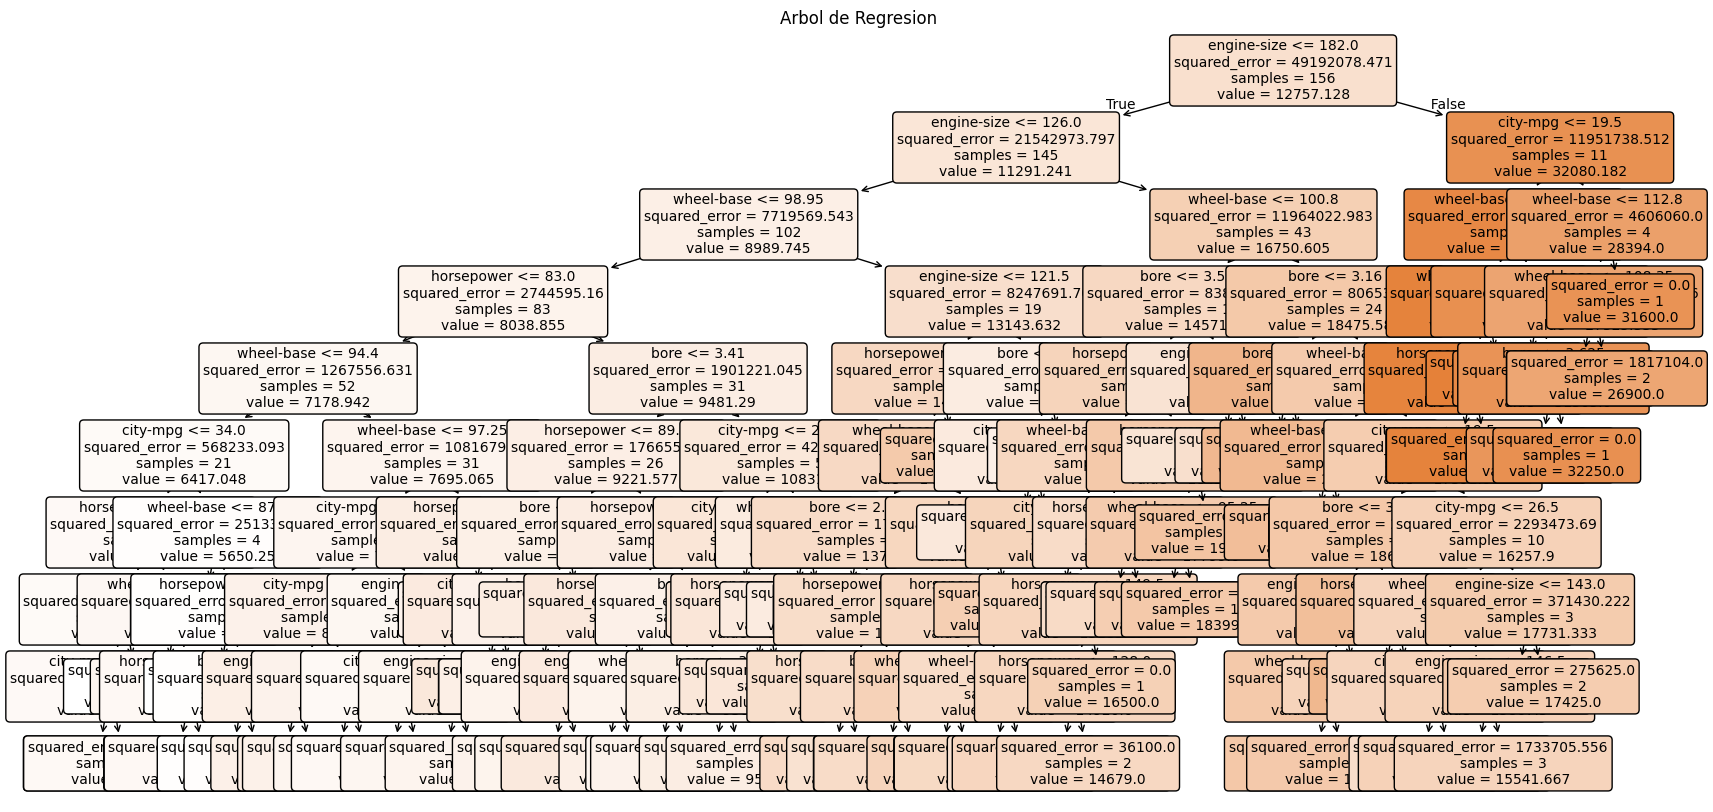

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Arbol de Regresion")
plt.show()

In [ ]:
# Ajustes de Parametros del Arbol de Decision

  # Entrenar modelo de regresion Lineal Multiple
tree_model = DecisionTreeRegressor(
    random_state = 42,
    max_depth = 7,
    min_samples_leaf=2,
    min_samples_split=10,
    max_features='sqrt',
    max_leaf_nodes=20)


tree_model.fit(X_train, y_train)

  # Evaluar Modelo
y_pred = tree_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R2): {r2:.2f}")

# Calcular el RMSE
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Error cuadrático medio (MSE): 8384044.54
Coeficiente de determinación (R2): 0.93
Raíz del Error cuadrático medio (RMSE): 2895.52


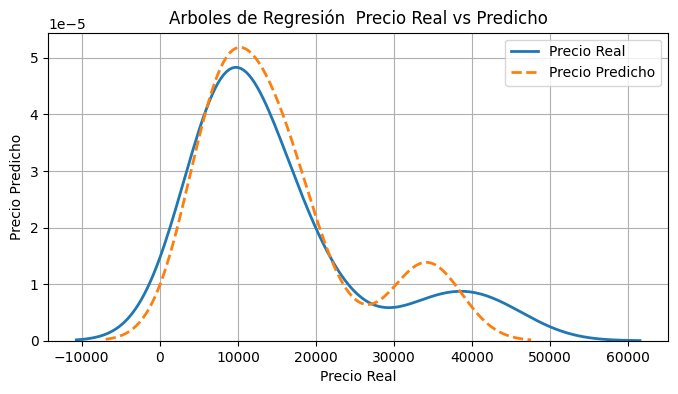

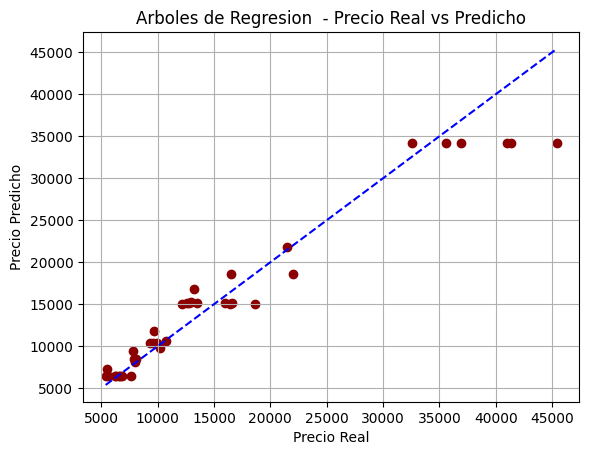

In [ ]:
# Comparar Precios Reales vs predichos
# Gráfica de densidad: Precio Real vs. Predicho
plt.figure(figsize=(8,4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de Regresión  Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica de dispersión: Precio Real vs. Predicho con línea ideal
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de Regresion  - Precio Real vs Predicho")
plt.grid(True)
plt.show()

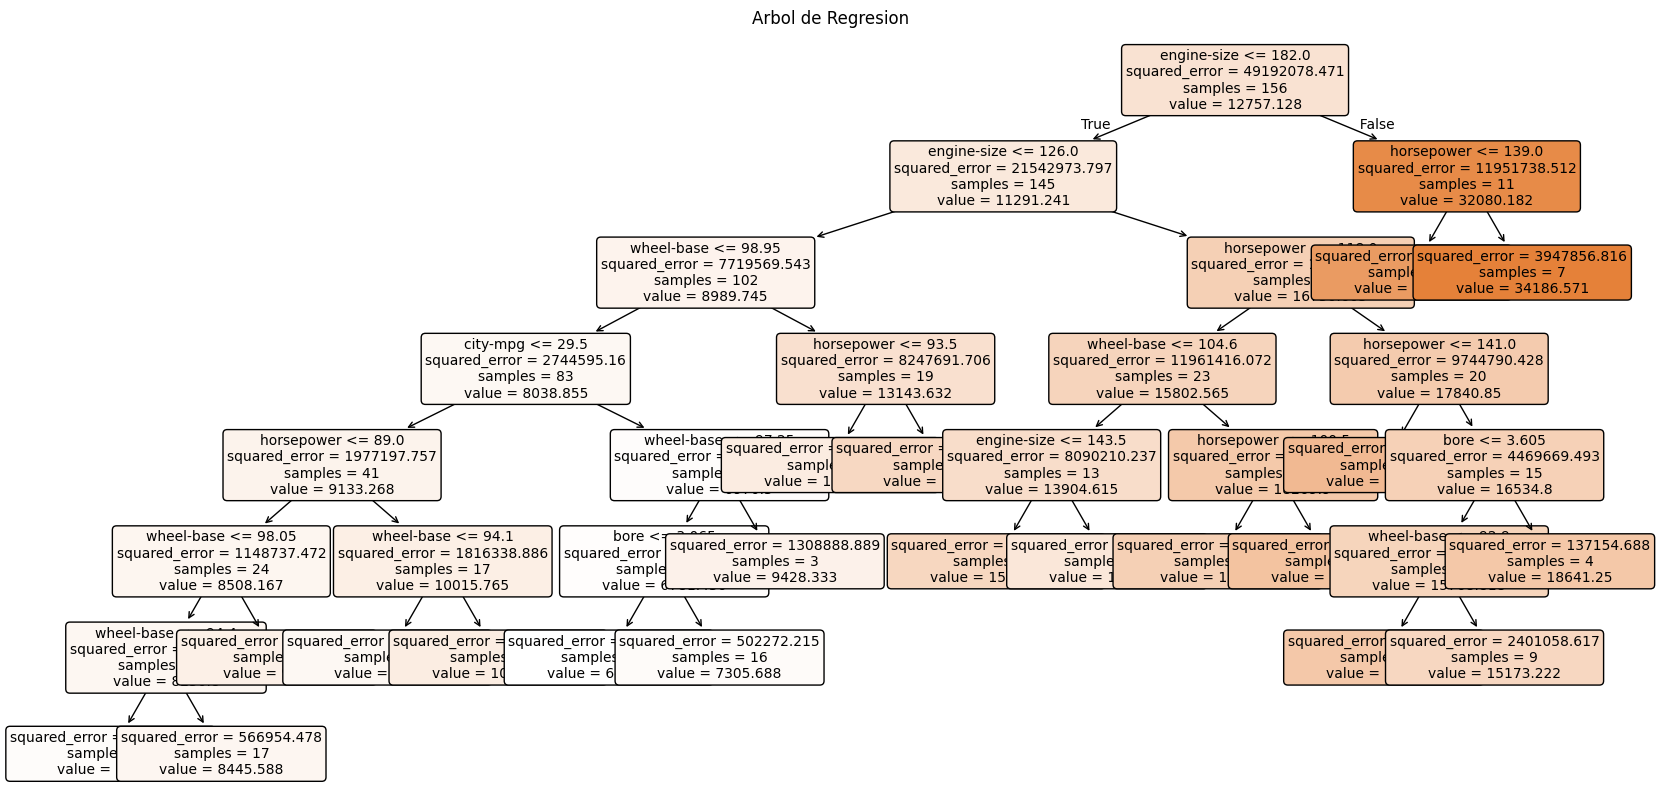

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Arbol de Regresion")
plt.show()